# 📊 Customer Support Ticket Analysis & Predictive Modeling

End-to-end Data Analytics + Machine Learning project  
Dataset: Customer Support Tickets (2020–2021)

## 🎯 Problem Statement

Businesses struggle with:
- High ticket backlog
- Slow response times
- Low customer satisfaction

This project aims to:
- Analyze support ticket data
- Identify bottlenecks
- Generate business insights
- Prepare data for Machine Learning

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 📂 Dataset Overview

Total Records: 8,469

Key Features:
- Ticket Details: type, subject, status, priority
- Customer Info: age, gender, rating
- Time Data: response time, resolution time
- Product & Channel Info

In [165]:
df=pd.read_excel("output.xlsx")
df.head()

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,resolution_time_hours,product_category,Status_Group
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22 04:37:52.762,Technical issue,Product setup,I'm having an issue with the {product_purchase...,NaN,Critical,Social media,2021-03-23 03:42:00,NaT,NaN,NaN,Cameras & Accessories,In Progress
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22 10:37:54.315,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,NaN,Critical,Chat,2021-05-23 05:30:00,NaT,NaN,NaN,Other,In Progress
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14 19:52:30.495,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Case maybe show recently my computer follow.,Low,Social media,2020-07-15 03:25:00,2020-07-15 07:58:00,3.0,4.550000,Computers & Software,Closed
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13 12:44:55.541,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Try capital clearly never color toward story.,Low,Social media,2020-11-14 02:26:00,2020-11-14 16:55:00,3.0,14.483333,Computers & Software,Closed
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04 03:12:07.491,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,West decision evidence bit.,Low,Email,2020-02-05 08:46:00,2020-02-05 14:05:00,1.0,5.316667,Computers & Software,Closed


In [166]:
df.shape

(8469, 19)

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     8469 non-null   int64         
 1   customer_name                 8469 non-null   object        
 2   customer_email                8469 non-null   object        
 3   customer_age                  8469 non-null   int64         
 4   customer_gender               8469 non-null   object        
 5   product_purchased             8469 non-null   object        
 6   date_of_purchase              8469 non-null   datetime64[ns]
 7   ticket_type                   8469 non-null   object        
 8   ticket_subject                8469 non-null   object        
 9   ticket_description            8469 non-null   object        
 10  resolution                    2769 non-null   object        
 11  ticket_priority               

In [168]:
df.describe()

,ticket_id,customer_age,date_of_purchase,first_response_time,time_to_resolution,customer_satisfaction_rating,resolution_time_hours
count,8469.000000,8469.000000,8469,5650,2769,2769.000000,2769.000000
mean,4235.000000,44.026804,2020-12-30 13:33:11.436043008,2020-12-30 01:48:15.122123776,2020-12-30 09:51:07.735644672,2.991333,9.611713
min,1.000000,18.000000,2020-01-01 01:46:11.410000,2020-01-02 08:56:00,2020-01-02 22:41:00,1.000000,3.600000
25%,2118.000000,31.000000,2020-07-02 01:05:57.721999872,2020-06-30 01:18:00,2020-06-30 21:20:00,2.000000,6.666667
50%,4235.000000,44.000000,2020-12-31 18:58:08.593999872,2020-12-28 06:59:30,2020-12-27 05:56:00,3.000000,9.633333
75%,6352.000000,57.000000,2021-07-01 04:49:34.299000064,2021-07-01 20:30:45,2021-07-02 17:37:00,4.000000,12.583333
max,8469.000000,70.000000,2021-12-30 23:59:03.613000,2021-12-31 11:48:00,2021-12-31 18:31:00,5.000000,15.600000
std,2444.934048,15.296112,NaN,NaN,NaN,1.407016,3.466508


In [169]:
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
customer_age                       0
customer_gender                    0
product_purchased                  0
date_of_purchase                   0
ticket_type                        0
ticket_subject                     0
ticket_description                 0
resolution                      5700
ticket_priority                    0
ticket_channel                     0
first_response_time             2819
time_to_resolution              5700
customer_satisfaction_rating    5700
resolution_time_hours           5700
product_category                   0
Status_Group                       0
dtype: int64

## 🧹 Data Cleaning & Preprocessing

Steps performed:
- Converted date columns to datetime
- Standardized column names
- Handled missing values
- Created derived features:
  - resolution_time_hours
  - Status_Group
  - age_group
  - product_category

In [170]:
df['date_of_purchase']=pd.to_datetime(df["date_of_purchase"])

In [171]:
df.columns =df.columns.str.strip().str.lower().str.replace(" ","_")

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     8469 non-null   int64         
 1   customer_name                 8469 non-null   object        
 2   customer_email                8469 non-null   object        
 3   customer_age                  8469 non-null   int64         
 4   customer_gender               8469 non-null   object        
 5   product_purchased             8469 non-null   object        
 6   date_of_purchase              8469 non-null   datetime64[ns]
 7   ticket_type                   8469 non-null   object        
 8   ticket_subject                8469 non-null   object        
 9   ticket_description            8469 non-null   object        
 10  resolution                    2769 non-null   object        
 11  ticket_priority               

In [173]:
df['first_response_time']=pd.to_datetime(df['first_response_time'])
df['time_to_resolution']=pd.to_datetime(df['time_to_resolution'])

## 📊 Exploratory Data Analysis (EDA)

Goal: Identify trends, bottlenecks, and patterns

Key Areas:
- Ticket volume trends
- Channel distribution
- Priority vs closure rate
- Customer satisfaction
- Product category analysis

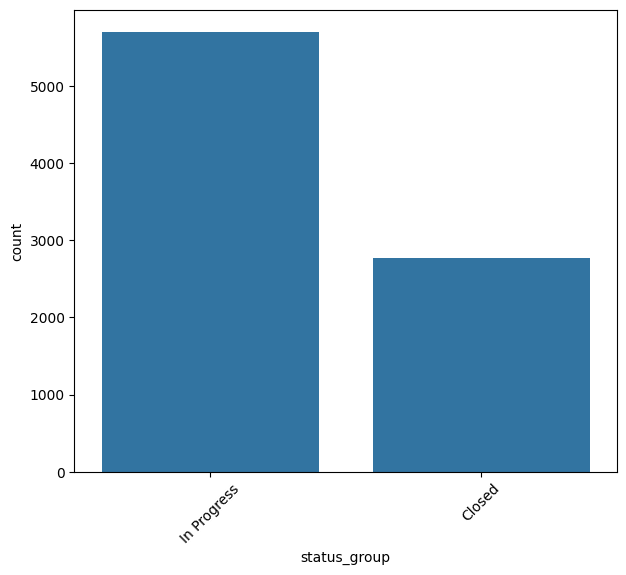

In [174]:
plt.figure(figsize=(7,6))
sns.countplot(x="status_group",data=df)
plt.xticks(rotation=45)
plt.show()

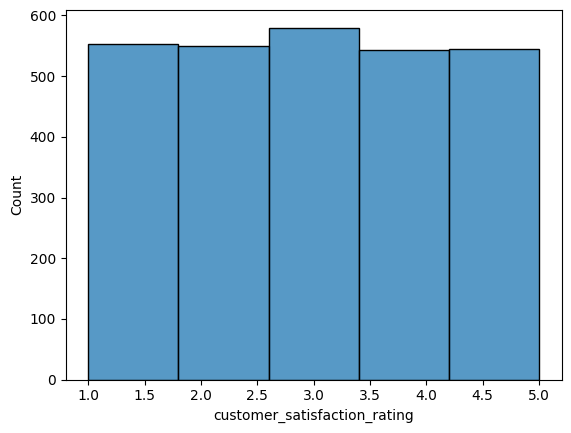

In [175]:
sns.histplot(df["customer_satisfaction_rating"],bins=5)
plt.show()

In [176]:
df['resolution_time_hours'] = (
    df['time_to_resolution'] - df['first_response_time']
).dt.total_seconds() / 3600

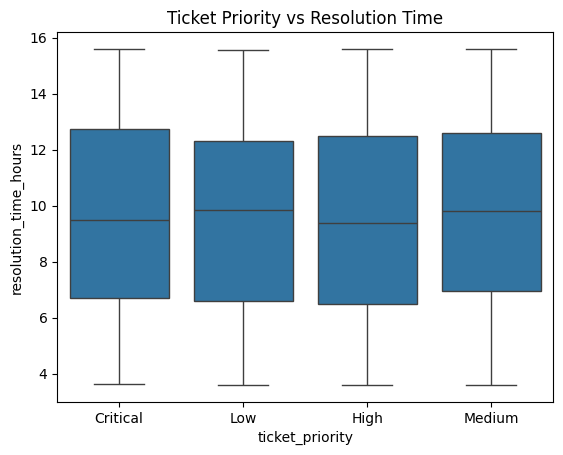

In [177]:
plt.Figure(figsize=(5,6))
sns.boxplot(x='ticket_priority',y='resolution_time_hours',data=df)
plt.title("Ticket Priority vs Resolution Time")
plt.show()

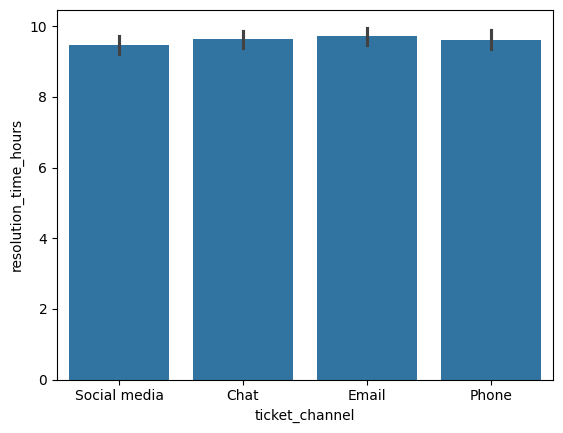

In [178]:
sns.barplot(x='ticket_channel', y='resolution_time_hours',data=df,estimator='mean')
plt.show()

In [179]:
df['month']=df['date_of_purchase'].dt.month

In [180]:
df.head(10)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,resolution_time_hours,product_category,status_group,month
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22 04:37:52.762,Technical issue,Product setup,I'm having an issue with the {product_purchase...,NaN,Critical,Social media,2021-03-23 03:42:00,NaT,NaN,NaN,Cameras & Accessories,In Progress,3
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22 10:37:54.315,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,NaN,Critical,Chat,2021-05-23 05:30:00,NaT,NaN,NaN,Other,In Progress,5
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14 19:52:30.495,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Case maybe show recently my computer follow.,Low,Social media,2020-07-15 03:25:00,2020-07-15 07:58:00,3.0,4.550000,Computers & Software,Closed,7
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13 12:44:55.541,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Try capital clearly never color toward story.,Low,Social media,2020-11-14 02:26:00,2020-11-14 16:55:00,3.0,14.483333,Computers & Software,Closed,11
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04 03:12:07.491,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,West decision evidence bit.,Low,Email,2020-02-05 08:46:00,2020-02-05 14:05:00,1.0,5.316667,Computers & Software,Closed,2
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28 01:21:13.048,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,NaN,Low,Social media,NaT,NaT,NaN,NaN,Computers & Software,In Progress,7
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23 06:17:31.576,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,NaN,Critical,Social media,NaT,NaT,NaN,NaN,Computers & Software,In Progress,2
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09 22:23:28.694,Refund request,Battery life,I'm having an issue with the {product_purchase...,NaN,Critical,Social media,NaT,NaT,NaN,NaN,Home Appliances & Smart Home,In Progress,8
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16 08:50:14.712,Technical issue,Installation support,I'm having an issue with the {product_purchase...,NaN,Low,Social media,2020-07-17 00:04:00,NaT,NaN,NaN,Electronics & Gadgets,In Progress,7
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06 09:37:40.565,Refund request,Payment issue,My {product_purchased} is making strange noise...,NaN,Critical,Phone,2020-03-07 03:50:00,NaT,NaN,NaN,Home Appliances & Smart Home,In Progress,3


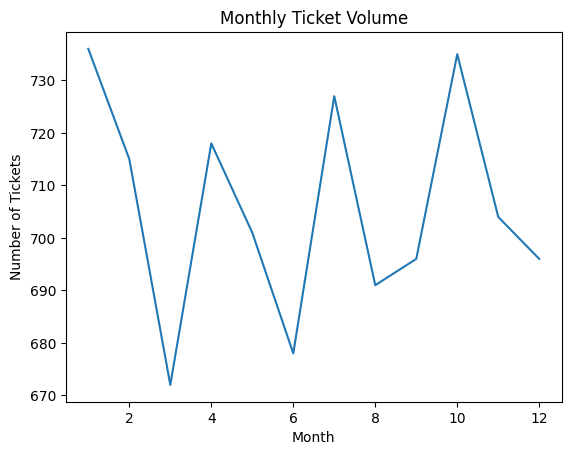

In [181]:

monthly_data = df.groupby('month').size().reset_index(name='ticket_count')
sns.lineplot(x='month', y='ticket_count', data=monthly_data)

plt.title("Monthly Ticket Volume")
plt.xlabel("Month")
plt.ylabel("Number of Tickets")
plt.show()

In [182]:
monthly_data

,month,ticket_count
0,1,736
1,2,715
2,3,672
3,4,718
4,5,701
5,6,678
6,7,727
7,8,691
8,9,696
9,10,735


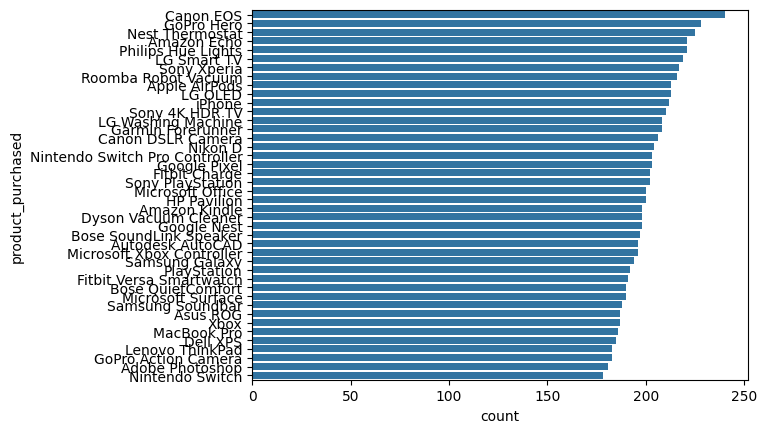

In [183]:
plt.Figure(figsize=(7,10))
sns.countplot(y='product_purchased', data=df, order=df['product_purchased'].value_counts().index)
plt.show()

## ⚙️ Feature Engineering

New Features Created:
- Encoded categorical variables
- Age groups
- Product categories
- Priority encoding

These features will help improve ML model performance.

In [184]:
def categorize_product(product):
    if product in ['iPhone','Samsung Galaxy','Google Pixel','Amazon Echo','Apple AirPods',
                   'Sony Xperia','Amazon Kindle','Fitbit Versa Smartwatch','Fitbit Charge',
                   'Garmin Forerunner']:
        return 'Electronics & Gadgets'
    
    elif product in ['Dell XPS','HP Pavilion','Lenovo ThinkPad','MacBook Pro',
                     'Microsoft Office','Adobe Photoshop','Autodesk AutoCAD','Microsoft Surface']:
        return 'Computers & Software'
    
    elif product in ['Nintendo Switch','Xbox','PlayStation','Microsoft Xbox Controller',
                     'Nintendo Switch Pro Controller','Sony PlayStation','Asus ROG']:
        return 'Gaming & Entertainment'
    
    elif product in ['Dyson Vacuum Cleaner','LG Washing Machine','Philips Hue Lights',
                     'Nest Thermostat','Roomba Robot Vacuum','Google Nest']:
        return 'Home Appliances & Smart Home'
    
    elif product in ['Canon EOS','Nikon D','GoPro Hero','GoPro Action Camera','Canon DSLR Camera']:
        return 'Cameras & Accessories'
    
    else:
        return 'Other'
    


df['product_category'] = df['product_purchased'].apply(categorize_product)

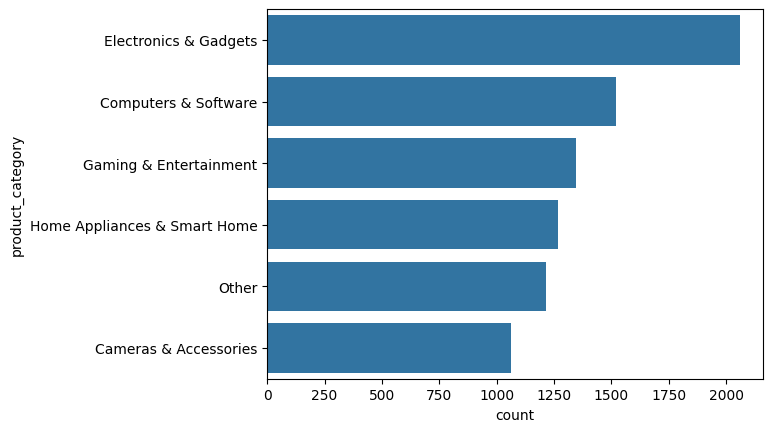

In [185]:
plt.Figure(figsize=(7,8))
sns.countplot(y='product_category',data=df,order=df['product_category'].value_counts().index)
plt.show()

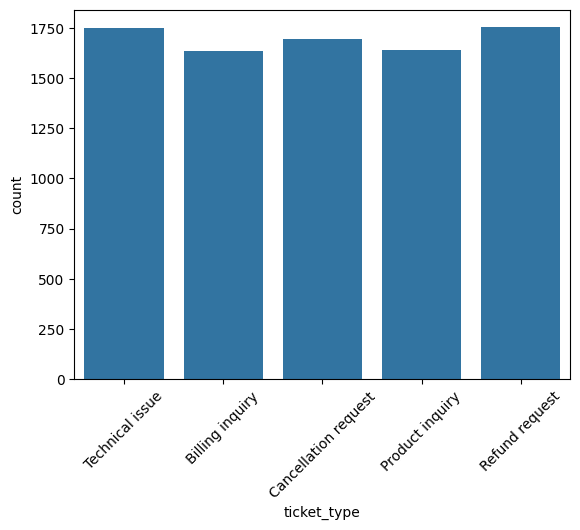

In [186]:
sns.countplot(x='ticket_type', data=df)
plt.xticks(rotation=45)
plt.show()

In [187]:
status_data=df.groupby(['ticket_type','status_group']).size().reset_index(name='count')

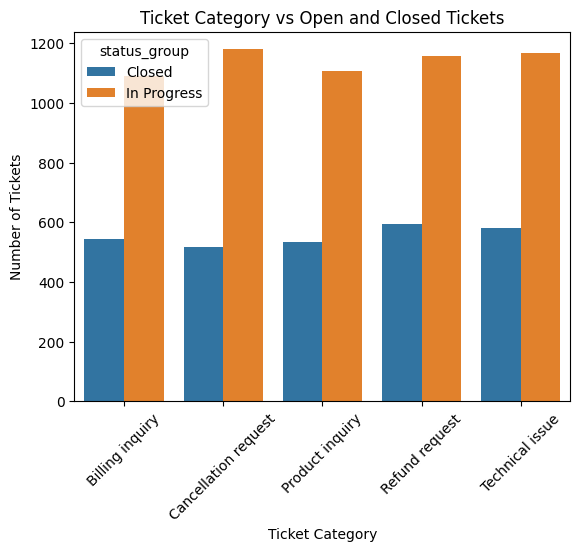

In [188]:
sns.barplot(
    x='ticket_type',y='count',hue='status_group',data=status_data
)
plt.title("Ticket Category vs Open and Closed Tickets")
plt.xlabel("Ticket Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

In [189]:
df1=df.copy()
df1.dropna(inplace=True)

In [190]:
df1.head(10)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,resolution_time_hours,product_category,status_group,month
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14 19:52:30.495,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Case maybe show recently my computer follow.,Low,Social media,2020-07-15 03:25:00,2020-07-15 07:58:00,3.0,4.550000,Computers & Software,Closed,7
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13 12:44:55.541,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Try capital clearly never color toward story.,Low,Social media,2020-11-14 02:26:00,2020-11-14 16:55:00,3.0,14.483333,Computers & Software,Closed,11
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04 03:12:07.491,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,West decision evidence bit.,Low,Email,2020-02-05 08:46:00,2020-02-05 14:05:00,1.0,5.316667,Computers & Software,Closed,2
10,11,Joseph Moreno,mbrown@example.org,48,Male,Nintendo Switch,2021-01-19 03:50:30.595,Cancellation request,Data loss,I'm having an issue with the {product_purchase...,Measure tonight surface feel forward.,High,Phone,2021-01-20 03:29:00,2021-01-20 17:24:00,1.0,13.916667,Gaming & Entertainment,Closed,1
11,12,Brandon Arnold,davisjohn@example.net,51,Male,Microsoft Xbox Controller,2021-10-24 17:48:07.392,Product inquiry,Software bug,I'm having an issue with the {product_purchase...,Measure there house management pick knowledge ...,High,Chat,2021-10-25 07:59:00,2021-10-25 22:36:00,1.0,14.616667,Gaming & Entertainment,Closed,10
14,15,Amy Hill,medinasteven@example.net,48,Female,Sony PlayStation,2020-02-29 13:53:21.277,Billing inquiry,Product setup,I'm having an issue with the {product_purchase...,Officer moment world sing parent available.,High,Chat,2020-03-01 00:11:00,2020-03-01 12:12:00,4.0,12.016667,Gaming & Entertainment,Closed,2
16,17,Julia Salazar,watkinsbarbara@example.com,63,Other,Xbox,2021-10-13 03:49:42.720,Product inquiry,Account access,I'm having an issue with the {product_purchase...,Seek evidence book collection catch.,Critical,Chat,2021-10-14 05:49:00,2021-10-14 13:00:00,4.0,7.183333,Gaming & Entertainment,Closed,10
19,20,Jeffrey Robertson,jameslopez@example.com,39,Female,Canon EOS,2021-03-08 21:01:08.192,Refund request,Software bug,I'm having an issue with the {product_purchase...,Wish mouth build resource though.,Low,Chat,2021-03-09 02:18:00,2021-03-09 07:50:00,5.0,5.533333,Cameras & Accessories,Closed,3
28,29,Christine Wang,garciastacy@example.com,30,Other,Fitbit Charge,2020-06-10 01:03:18.356,Technical issue,Product recommendation,I'm having an issue with the {product_purchase...,Soldier we such inside.,Critical,Phone,2020-06-11 02:57:00,2020-06-11 13:22:00,5.0,10.416667,Electronics & Gadgets,Closed,6
29,30,Austin George,shericase@example.net,67,Male,Xbox,2020-12-26 22:44:14.175,Cancellation request,Cancellation request,I'm having an issue with the {product_purchase...,Firm sort voice above which site arrive.,Medium,Phone,2020-12-27 12:01:00,2020-12-27 22:57:00,1.0,10.933333,Gaming & Entertainment,Closed,12


In [191]:
gender_data=df.groupby(['customer_gender','status_group']).size().reset_index(name='ticket_count')

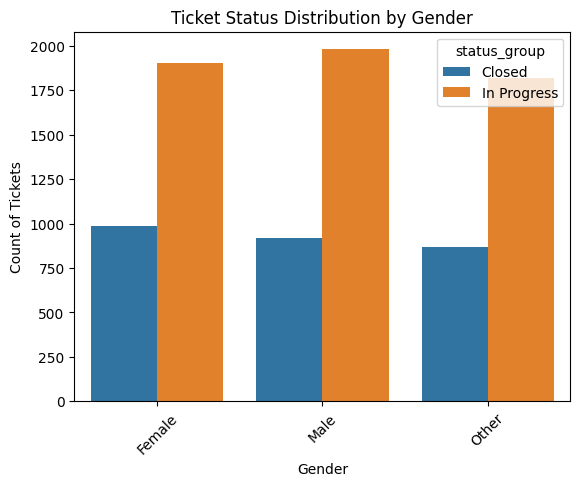

In [192]:
sns.barplot(x='customer_gender',y='ticket_count',hue='status_group',data=gender_data)
plt.title("Ticket Status Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count of Tickets")
plt.xticks(rotation=45)
plt.show()

In [193]:
df['gender_encoded'] = df['customer_gender'].map({
    'Male': 1,
    'Female':2,
    'Other':0
})

In [194]:
df['type_encoded']=df['ticket_type'].map({
    'Refund request':4,
    'Technical issue':3,
    'Billing inquiry':2,
    'Product inquiry':1,
    'Refund request':0
})

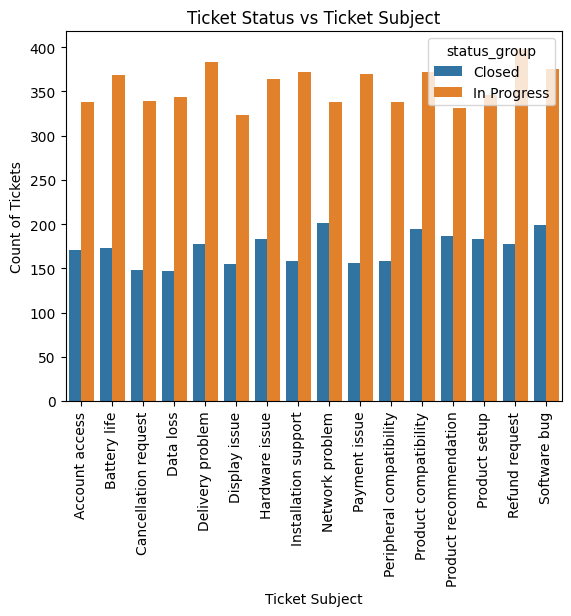

In [195]:
subject_data=df.groupby(['ticket_subject','status_group']).size().reset_index(name='count')
sns.barplot(x='ticket_subject',y='count',hue='status_group',data=subject_data)
plt.title("Ticket Status vs Ticket Subject")
plt.xlabel("Ticket Subject")
plt.ylabel("Count of Tickets")
plt.xticks(rotation=90)
plt.show()

In [196]:
df.head(10)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,resolution_time_hours,product_category,status_group,month,gender_encoded,type_encoded
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22 04:37:52.762,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,Social media,2021-03-23 03:42:00,NaT,NaN,NaN,Cameras & Accessories,In Progress,3,0,3.0
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22 10:37:54.315,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,Chat,2021-05-23 05:30:00,NaT,NaN,NaN,Other,In Progress,5,2,3.0
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14 19:52:30.495,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,Social media,2020-07-15 03:25:00,2020-07-15 07:58:00,3.0,4.550000,Computers & Software,Closed,7,0,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13 12:44:55.541,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,Social media,2020-11-14 02:26:00,2020-11-14 16:55:00,3.0,14.483333,Computers & Software,Closed,11,2,2.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04 03:12:07.491,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,Email,2020-02-05 08:46:00,2020-02-05 14:05:00,1.0,5.316667,Computers & Software,Closed,2,2,2.0
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28 01:21:13.048,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,...,Social media,NaT,NaT,NaN,NaN,Computers & Software,In Progress,7,1,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23 06:17:31.576,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,...,Social media,NaT,NaT,NaN,NaN,Computers & Software,In Progress,2,0,1.0
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09 22:23:28.694,Refund request,Battery life,I'm having an issue with the {product_purchase...,...,Social media,NaT,NaT,NaN,NaN,Home Appliances & Smart Home,In Progress,8,1,0.0
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16 08:50:14.712,Technical issue,Installation support,I'm having an issue with the {product_purchase...,...,Social media,2020-07-17 00:04:00,NaT,NaN,NaN,Electronics & Gadgets,In Progress,7,0,3.0
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06 09:37:40.565,Refund request,Payment issue,My {product_purchased} is making strange noise...,...,Phone,2020-03-07 03:50:00,NaT,NaN,NaN,Home Appliances & Smart Home,In Progress,3,1,0.0


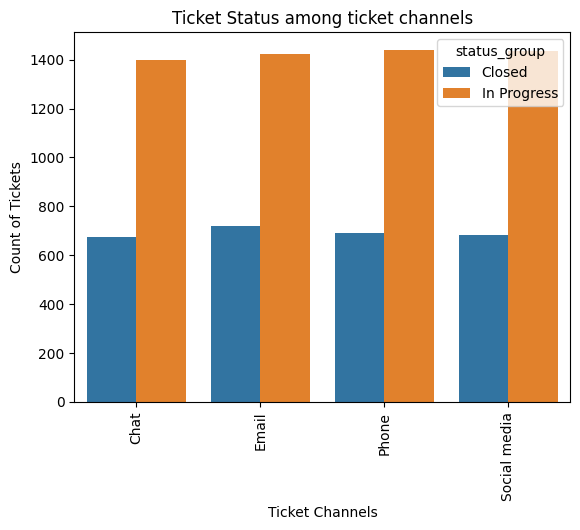

In [197]:
channel_data=df.groupby(['ticket_channel','status_group']).size().reset_index(name='count')
sns.barplot(x='ticket_channel',y='count',hue='status_group',data=channel_data)
plt.title("Ticket Status among ticket channels")
plt.xlabel("Ticket Channels")
plt.ylabel("Count of Tickets")
plt.xticks(rotation=90)
plt.show()

In [198]:
df['channel_encoded']=df['ticket_channel'].map({
    'Email':3,
    'Phone':2,
    'Social media':1,
    'Chat':0
})

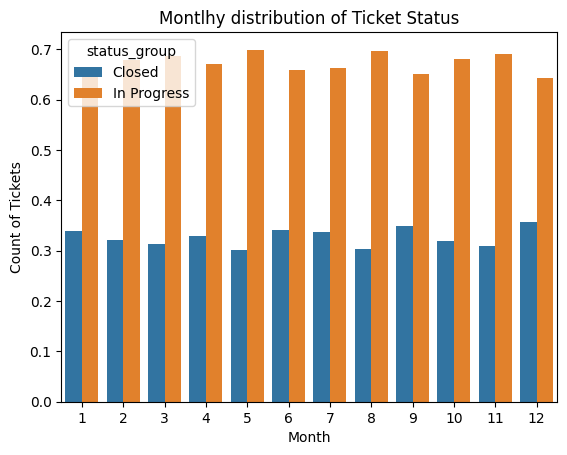

In [199]:
monthly_data=df.groupby(['month','status_group']).size().reset_index(name='count')
monthly_total = monthly_data.groupby('month')['count'].transform('sum')
monthly_data['percentage'] = monthly_data['count'] / monthly_total
sns.barplot(x='month',y='percentage',hue='status_group',data=monthly_data)
plt.title("Montlhy distribution of Ticket Status")
plt.xlabel("Month")
plt.ylabel("Count of Tickets")
plt.show()

In [200]:
df.head(10)


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,first_response_time,time_to_resolution,customer_satisfaction_rating,resolution_time_hours,product_category,status_group,month,gender_encoded,type_encoded,channel_encoded
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22 04:37:52.762,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,2021-03-23 03:42:00,NaT,NaN,NaN,Cameras & Accessories,In Progress,3,0,3.0,1
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22 10:37:54.315,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,2021-05-23 05:30:00,NaT,NaN,NaN,Other,In Progress,5,2,3.0,0
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14 19:52:30.495,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,2020-07-15 03:25:00,2020-07-15 07:58:00,3.0,4.550000,Computers & Software,Closed,7,0,3.0,1
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13 12:44:55.541,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,2020-11-14 02:26:00,2020-11-14 16:55:00,3.0,14.483333,Computers & Software,Closed,11,2,2.0,1
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04 03:12:07.491,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,2020-02-05 08:46:00,2020-02-05 14:05:00,1.0,5.316667,Computers & Software,Closed,2,2,2.0,3
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28 01:21:13.048,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,...,NaT,NaT,NaN,NaN,Computers & Software,In Progress,7,1,NaN,1
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23 06:17:31.576,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,...,NaT,NaT,NaN,NaN,Computers & Software,In Progress,2,0,1.0,1
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09 22:23:28.694,Refund request,Battery life,I'm having an issue with the {product_purchase...,...,NaT,NaT,NaN,NaN,Home Appliances & Smart Home,In Progress,8,1,0.0,1
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16 08:50:14.712,Technical issue,Installation support,I'm having an issue with the {product_purchase...,...,2020-07-17 00:04:00,NaT,NaN,NaN,Electronics & Gadgets,In Progress,7,0,3.0,1
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06 09:37:40.565,Refund request,Payment issue,My {product_purchased} is making strange noise...,...,2020-03-07 03:50:00,NaT,NaN,NaN,Home Appliances & Smart Home,In Progress,3,1,0.0,2


In [201]:
df['age_group'] = pd.cut(df['customer_age'],
                        bins=[17, 25, 35, 50, 70],
                        labels=['18-25', '26-35', '36-50', '50+'])

In [202]:
age_data=df.groupby(['age_group','ticket_type']).size().reset_index(name='count')
age_ticket_pivot = age_data.pivot(index='age_group',
                                    columns='ticket_type',
                                    values='count').fillna(0)

C:\Users\moizikha\AppData\Local\Temp\ipykernel_18420\3737842650.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_data=df.groupby(['age_group','ticket_type']).size().reset_index(name='count')


C:\Users\moizikha\AppData\Local\Temp\ipykernel_18420\1467212273.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_status_data=df.groupby(['age_group','status_group']).size().reset_index(name='count')


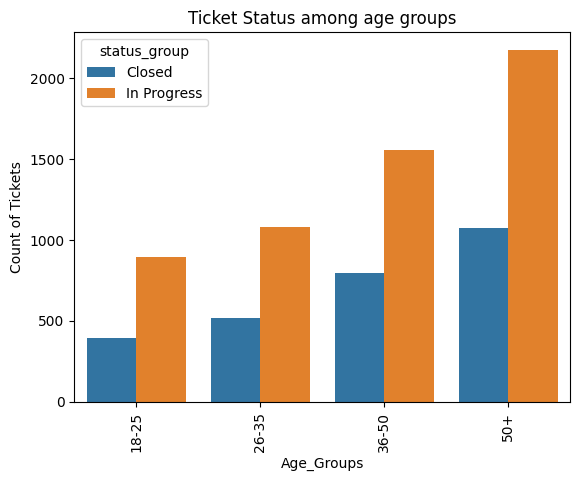

In [203]:
age_status_data=df.groupby(['age_group','status_group']).size().reset_index(name='count')
sns.barplot(x='age_group',y='count',hue='status_group',data=age_status_data)
plt.title("Ticket Status among age groups")
plt.xlabel("Age_Groups")
plt.ylabel("Count of Tickets")
plt.xticks(rotation=90)
plt.show()

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     8469 non-null   int64         
 1   customer_name                 8469 non-null   object        
 2   customer_email                8469 non-null   object        
 3   customer_age                  8469 non-null   int64         
 4   customer_gender               8469 non-null   object        
 5   product_purchased             8469 non-null   object        
 6   date_of_purchase              8469 non-null   datetime64[ns]
 7   ticket_type                   8469 non-null   object        
 8   ticket_subject                8469 non-null   object        
 9   ticket_description            8469 non-null   object        
 10  resolution                    2769 non-null   object        
 11  ticket_priority               

In [205]:
category_resolution = df[df['status_group'] == 'Closed'] .groupby('age_group')['customer_satisfaction_rating'] .mean() .reset_index(name="avg_time")

C:\Users\moizikha\AppData\Local\Temp\ipykernel_18420\3490851511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_resolution = df[df['status_group'] == 'Closed'] .groupby('age_group')['customer_satisfaction_rating'] .mean() .reset_index(name="avg_time")


In [206]:
category_resolution

,age_group,avg_time
0,18-25,2.964103
1,26-35,3.048544
2,36-50,2.997478
3,50+,2.969188


In [207]:
df.head(10)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,time_to_resolution,customer_satisfaction_rating,resolution_time_hours,product_category,status_group,month,gender_encoded,type_encoded,channel_encoded,age_group
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22 04:37:52.762,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,NaT,NaN,NaN,Cameras & Accessories,In Progress,3,0,3.0,1,26-35
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22 10:37:54.315,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,NaT,NaN,NaN,Other,In Progress,5,2,3.0,0,36-50
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14 19:52:30.495,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,2020-07-15 07:58:00,3.0,4.550000,Computers & Software,Closed,7,0,3.0,1,36-50
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13 12:44:55.541,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,2020-11-14 16:55:00,3.0,14.483333,Computers & Software,Closed,11,2,2.0,1,26-35
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04 03:12:07.491,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,2020-02-05 14:05:00,1.0,5.316667,Computers & Software,Closed,2,2,2.0,3,50+
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28 01:21:13.048,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,...,NaT,NaN,NaN,Computers & Software,In Progress,7,1,NaN,1,50+
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23 06:17:31.576,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,...,NaT,NaN,NaN,Computers & Software,In Progress,2,0,1.0,1,18-25
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09 22:23:28.694,Refund request,Battery life,I'm having an issue with the {product_purchase...,...,NaT,NaN,NaN,Home Appliances & Smart Home,In Progress,8,1,0.0,1,18-25
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16 08:50:14.712,Technical issue,Installation support,I'm having an issue with the {product_purchase...,...,NaT,NaN,NaN,Electronics & Gadgets,In Progress,7,0,3.0,1,50+
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06 09:37:40.565,Refund request,Payment issue,My {product_purchased} is making strange noise...,...,NaT,NaN,NaN,Home Appliances & Smart Home,In Progress,3,1,0.0,2,26-35


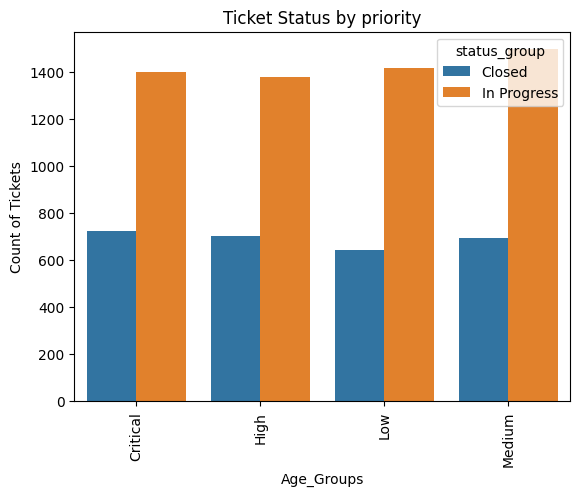

In [208]:
ticket_priority_data=df.groupby(['ticket_priority','status_group']).size().reset_index(name='count')
sns.barplot(x='ticket_priority',y='count',hue='status_group',data=ticket_priority_data)
plt.title("Ticket Status by priority")
plt.xlabel("Age_Groups")
plt.ylabel("Count of Tickets")
plt.xticks(rotation=90)
plt.show()

In [209]:
priority_status = df.groupby(['ticket_priority','status_group']).size().unstack()
priority_status['closure_rate'] = priority_status['Closed'] / priority_status.sum(axis=1)
priority_status

status_group,Closed,In Progress,closure_rate
ticket_priority,,,
Critical,726,1403,0.341005
High,705,1380,0.338129
Low,644,1419,0.312167
Medium,694,1498,0.316606


Text(0.5, 1.0, 'Closure Efficiency by Ticket Priority')

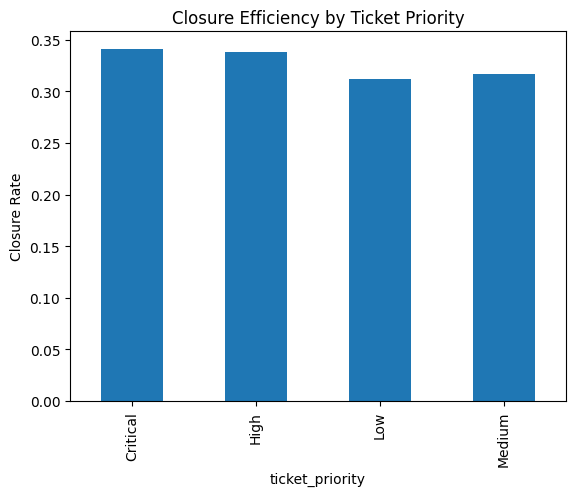

In [210]:
priority_status['closure_rate'].plot(kind='bar')
plt.ylabel("Closure Rate")
plt.title("Closure Efficiency by Ticket Priority")

In [211]:
df['priority_encoded']=df['ticket_priority'].map({
    'Critical':3,
    'High':2,
    'Medium':1,
    'Low':0
})

In [212]:
prduct_category_status = df.groupby(['product_category','status_group']).size().unstack()
prduct_category_status['closure_rate'] = prduct_category_status['Closed'] / prduct_category_status.sum(axis=1)
prduct_category_status

status_group,Closed,In Progress,closure_rate
product_category,,,
Cameras & Accessories,372,689,0.350613
Computers & Software,479,1042,0.314924
Electronics & Gadgets,694,1365,0.337057
Gaming & Entertainment,414,931,0.307807
Home Appliances & Smart Home,401,865,0.316746
Other,409,808,0.336072


In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     8469 non-null   int64         
 1   customer_name                 8469 non-null   object        
 2   customer_email                8469 non-null   object        
 3   customer_age                  8469 non-null   int64         
 4   customer_gender               8469 non-null   object        
 5   product_purchased             8469 non-null   object        
 6   date_of_purchase              8469 non-null   datetime64[ns]
 7   ticket_type                   8469 non-null   object        
 8   ticket_subject                8469 non-null   object        
 9   ticket_description            8469 non-null   object        
 10  resolution                    2769 non-null   object        
 11  ticket_priority               

In [214]:
df['category_encoded']=df['product_category'].map({
    'Cameras & Accessories':5,
    'Electronics & Gadgets':4,
    'Other':3,
    'Home Appliances & Smart Home':2,
    'Computers & Software':1,
    'Gaming & Entertainment':0
})

In [215]:
df.head(10)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,resolution_time_hours,product_category,status_group,month,gender_encoded,type_encoded,channel_encoded,age_group,priority_encoded,category_encoded
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22 04:37:52.762,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,NaN,Cameras & Accessories,In Progress,3,0,3.0,1,26-35,3,5
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22 10:37:54.315,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,NaN,Other,In Progress,5,2,3.0,0,36-50,3,3
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14 19:52:30.495,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,4.550000,Computers & Software,Closed,7,0,3.0,1,36-50,0,1
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13 12:44:55.541,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,14.483333,Computers & Software,Closed,11,2,2.0,1,26-35,0,1
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04 03:12:07.491,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,5.316667,Computers & Software,Closed,2,2,2.0,3,50+,0,1
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28 01:21:13.048,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,...,NaN,Computers & Software,In Progress,7,1,NaN,1,50+,0,1
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23 06:17:31.576,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,...,NaN,Computers & Software,In Progress,2,0,1.0,1,18-25,3,1
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09 22:23:28.694,Refund request,Battery life,I'm having an issue with the {product_purchase...,...,NaN,Home Appliances & Smart Home,In Progress,8,1,0.0,1,18-25,3,2
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16 08:50:14.712,Technical issue,Installation support,I'm having an issue with the {product_purchase...,...,NaN,Electronics & Gadgets,In Progress,7,0,3.0,1,50+,0,4
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06 09:37:40.565,Refund request,Payment issue,My {product_purchased} is making strange noise...,...,NaN,Home Appliances & Smart Home,In Progress,3,1,0.0,2,26-35,3,2


In [228]:
df_ml=df.copy()

In [229]:
df_ml = df_ml.drop(columns=[
    'ticket_id',
    'ticket_subject',
    'product_purchased',
    'date_of_purchase',
    'first_response_time',
    'time_to_resolution'
])

In [230]:
df_ml['status_group'] = df_ml['status_group'].map({
    'Closed':1,
    'In Progress':0
})

In [231]:
df_ml

,customer_name,customer_email,customer_age,customer_gender,ticket_type,ticket_description,resolution,ticket_priority,ticket_channel,customer_satisfaction_rating,resolution_time_hours,product_category,status_group,month,gender_encoded,type_encoded,channel_encoded,age_group,priority_encoded,category_encoded
0,Marisa Obrien,carrollallison@example.com,32,Other,Technical issue,I'm having an issue with the {product_purchase...,NaN,Critical,Social media,NaN,NaN,Cameras & Accessories,0,3,0,3.0,1,26-35,3,5
1,Jessica Rios,clarkeashley@example.com,42,Female,Technical issue,I'm having an issue with the {product_purchase...,NaN,Critical,Chat,NaN,NaN,Other,0,5,2,3.0,0,36-50,3,3
2,Christopher Robbins,gonzalestracy@example.com,48,Other,Technical issue,I'm facing a problem with my {product_purchase...,Case maybe show recently my computer follow.,Low,Social media,3.0,4.550000,Computers & Software,1,7,0,3.0,1,36-50,0,1
3,Christina Dillon,bradleyolson@example.org,27,Female,Billing inquiry,I'm having an issue with the {product_purchase...,Try capital clearly never color toward story.,Low,Social media,3.0,14.483333,Computers & Software,1,11,2,2.0,1,26-35,0,1
4,Alexander Carroll,bradleymark@example.com,67,Female,Billing inquiry,I'm having an issue with the {product_purchase...,West decision evidence bit.,Low,Email,1.0,5.316667,Computers & Software,1,2,2,2.0,3,50+,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,David Todd,adam28@example.net,22,Female,Product inquiry,My {product_purchased} is making strange noise...,NaN,Low,Phone,NaN,NaN,Other,0,12,2,1.0,2,18-25,0,3
8465,Lori Davis,russell68@example.com,27,Female,Technical issue,I'm having an issue with the {product_purchase...,NaN,Critical,Email,NaN,NaN,Other,0,2,2,3.0,3,26-35,3,3
8466,Michelle Kelley,ashley83@example.org,57,Female,Technical issue,I'm having an issue with the {product_purchase...,Eight account century nature kitchen.,High,Social media,3.0,9.716667,Cameras & Accessories,1,8,2,3.0,1,50+,2,5
8467,Steven Rodriguez,fpowell@example.org,54,Male,Product inquiry,I'm having an issue with the {product_purchase...,We seat culture plan.,Medium,Email,3.0,11.666667,Gaming & Entertainment,1,10,1,1.0,3,50+,1,0


In [232]:
drop_cols = [
    'customer_name',
    'customer_email',
    'ticket_description',
    'resolution',
    'resolution_time_hours',
    'customer_satisfaction_rating',
    'age_group'
]

df_ml = df_ml.drop(columns=drop_cols)

In [233]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'ticket_type',
    'ticket_priority',
    'ticket_channel',
    'product_category'
]

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

In [234]:
df_ml = df_ml.drop(columns=[
    'type_encoded',
    'channel_encoded',
    'priority_encoded',
    'category_encoded'
])

In [235]:
df_ml['status_group'] = df_ml['status_group'].astype(int)

In [236]:
df_ml = pd.get_dummies(df_ml, columns=['month'], drop_first=True)

In [237]:
df_ml.info()
df_ml.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_age      8469 non-null   int64 
 1   customer_gender   8469 non-null   object
 2   ticket_type       8469 non-null   int64 
 3   ticket_priority   8469 non-null   int64 
 4   ticket_channel    8469 non-null   int64 
 5   product_category  8469 non-null   int64 
 6   status_group      8469 non-null   int64 
 7   gender_encoded    8469 non-null   int64 
 8   month_2           8469 non-null   bool  
 9   month_3           8469 non-null   bool  
 10  month_4           8469 non-null   bool  
 11  month_5           8469 non-null   bool  
 12  month_6           8469 non-null   bool  
 13  month_7           8469 non-null   bool  
 14  month_8           8469 non-null   bool  
 15  month_9           8469 non-null   bool  
 16  month_10          8469 non-null   bool  
 17  month_11      

,customer_age,customer_gender,ticket_type,ticket_priority,ticket_channel,product_category,status_group,gender_encoded,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,32,Other,4,0,3,0,0,0,False,True,False,False,False,False,False,False,False,False,False
1,42,Female,4,0,0,5,0,2,False,False,False,True,False,False,False,False,False,False,False
2,48,Other,4,2,3,1,1,0,False,False,False,False,False,True,False,False,False,False,False
3,27,Female,0,2,3,1,1,2,False,False,False,False,False,False,False,False,False,True,False
4,67,Female,0,2,1,1,1,2,True,False,False,False,False,False,False,False,False,False,False


In [238]:
df_ml=df_ml.drop(columns=['customer_gender'])

In [239]:
df_ml.head()

,customer_age,ticket_type,ticket_priority,ticket_channel,product_category,status_group,gender_encoded,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,32,4,0,3,0,0,0,False,True,False,False,False,False,False,False,False,False,False
1,42,4,0,0,5,0,2,False,False,False,True,False,False,False,False,False,False,False
2,48,4,2,3,1,1,0,False,False,False,False,False,True,False,False,False,False,False
3,27,0,2,3,1,1,2,False,False,False,False,False,False,False,False,False,True,False
4,67,0,2,1,1,1,2,True,False,False,False,False,False,False,False,False,False,False
